# Dog Skin Disease Classification — Dataset Preprocessing & Feature Engineering

**Group Assignment: CSC60904 — Deep Learning**
 Dataset Preprocessing Engineering & Feature Engineering**

This notebook covers everything from loading the raw dataset to producing a
clean, preprocessed, feature-engineered `tf.data` pipeline that is ready to be
handed to the modelling team for training.

**Sections covered:**
1. Setting Up Environment
2. Dataset Overview
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Data Preprocessing
6. Feature Engineering
7. Final TensorFlow Data Pipeline


## 1. Setting Up Environment

### 1.1. Importing Essential Libraries

In [1]:
import os
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


* **os** — used to navigate folders, list files, and count images.
* **hashlib** — used to fingerprint image files so we can detect duplicates.
* **numpy** — used for numerical operations on image arrays.
* **pandas** — used to organise dataset statistics and engineered features into tables.
* **matplotlib.pyplot** — used to visualise class distribution and sample images.
* **PIL (Image)** — used to open images and check their size/format/mode.
* **cv2 (OpenCV)** — used in the Feature Engineering section to compute image features (edges, colour histograms).
* **tensorflow** — the main deep learning framework, used to build the final data pipeline.


### 1.2. Downloading the Kaggle Dataset

Mounting Google Drive

In [2]:
# Mount Google Drive to access the Kaggle API key
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Create the .kaggle folder
!mkdir -p ~/.kaggle

# Copy the API key from Google Drive
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

# Set the correct permissions
!chmod 600 ~/.kaggle/kaggle.json
# Install the Kaggle API (skip if already installed)
!pip install -q kaggle

# Download the Dog Skin Disease dataset from Kaggle
!kaggle datasets download -d youssefmohmmed/dogs-skin-diseases-image-dataset

# Extract the downloaded dataset into the "dataset" folder
!unzip -oq dogs-skin-diseases-image-dataset.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/youssefmohmmed/dogs-skin-diseases-image-dataset
License(s): apache-2.0
dogs-skin-diseases-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


* `files.upload()` lets us upload our personal Kaggle API token.
* The `!mkdir` / `!cp` / `!chmod` lines place the token where the Kaggle CLI expects it.
* `!kaggle datasets download` fetches the dataset directly into Colab — this keeps the
  notebook reproducible for the whole team, instead of manually sharing zip files.
* `!unzip` extracts everything into a local `dataset` folder.


### 1.3. Setting Dataset Paths

In [4]:
# Define the main dataset folder
base_dir = "dataset"

# Define the paths for the training, validation, and test sets
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

# Display the dataset paths
print("Training Folder :", train_dir)
print("Validation Folder:", valid_dir)
print("Test Folder      :", test_dir)

Training Folder : dataset/train
Validation Folder: dataset/valid
Test Folder      : dataset/test


* We store each split's path in a variable once, instead of repeating the string
  everywhere. This avoids typos and makes the notebook easier to maintain.


## 2. Dataset Overview

### 2.1. Verifying Dataset Structure

In [5]:
# Get the list of disease classes from each dataset split
train_classes = sorted(os.listdir(train_dir))
valid_classes = sorted(os.listdir(valid_dir))
test_classes = sorted(os.listdir(test_dir))

# Display the class names
print("Classes:")
print(train_classes)

# Check if all dataset splits contain the same classes
print("\nSame classes in train, validation, and test:",
      train_classes == valid_classes == test_classes)

Classes:
['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']

Same classes in train, validation, and test: True


* We list the sub-folders (classes) inside each split and confirm they match.
* This dataset contains **6 disease classes**: Dermatitis, Fungal_infections, Healthy,
  Hypersensitivity, demodicosis, ringworm — consistent across train/valid/test.


### 2.2. Dataset Statistics

In [6]:
def count_images(directory):
    return {c: len(os.listdir(os.path.join(directory, c))) for c in sorted(os.listdir(directory))}

train_counts = count_images(train_dir)
valid_counts = count_images(valid_dir)
test_counts  = count_images(test_dir)

# Combine into one summary table
df_counts = pd.DataFrame({"Train": train_counts, "Validation": valid_counts, "Test": test_counts})
df_counts["Total"] = df_counts.sum(axis=1)
df_counts.loc["Total"] = df_counts.sum()

df_counts

,Train,Validation,Test,Total
Dermatitis,546,175,66,787
Fungal_infections,375,97,54,526
Healthy,492,139,69,700
Hypersensitivity,230,63,29,322
demodicosis,588,174,100,862
ringworm,791,212,115,1118
Total,3022,860,433,4315


* This table is the core evidence for the **Dataset Description** section of the report:
  it shows the number of images per class, per split, and the overall dataset size
  (4,315 images across 6 classes before cleaning).


## 3. Exploratory Data Analysis (EDA)

### 3.1. Class Distribution

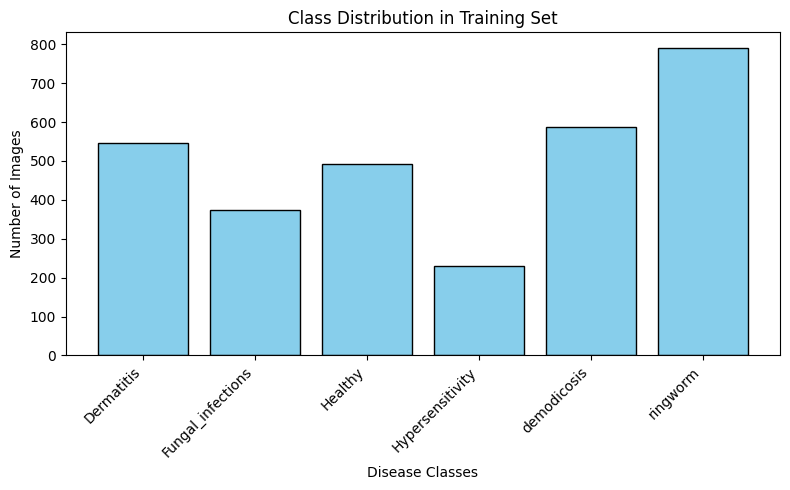

In [7]:
# Get the class names and corresponding image counts
classes = list(train_counts.keys())
counts = list(train_counts.values())

# Plot the class distribution of the training dataset
plt.figure(figsize=(8, 5))
plt.bar(classes, counts, color="skyblue", edgecolor="black")

plt.title("Class Distribution in Training Set")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

* The bar chart makes class imbalance obvious: **ringworm** (791 images) has more than
  **3x** the images of **Hypersensitivity** (230 images). We account for this later using
  class weights during training and by not over-relying on accuracy alone during evaluation.


### 3.2. Sample Images per Class

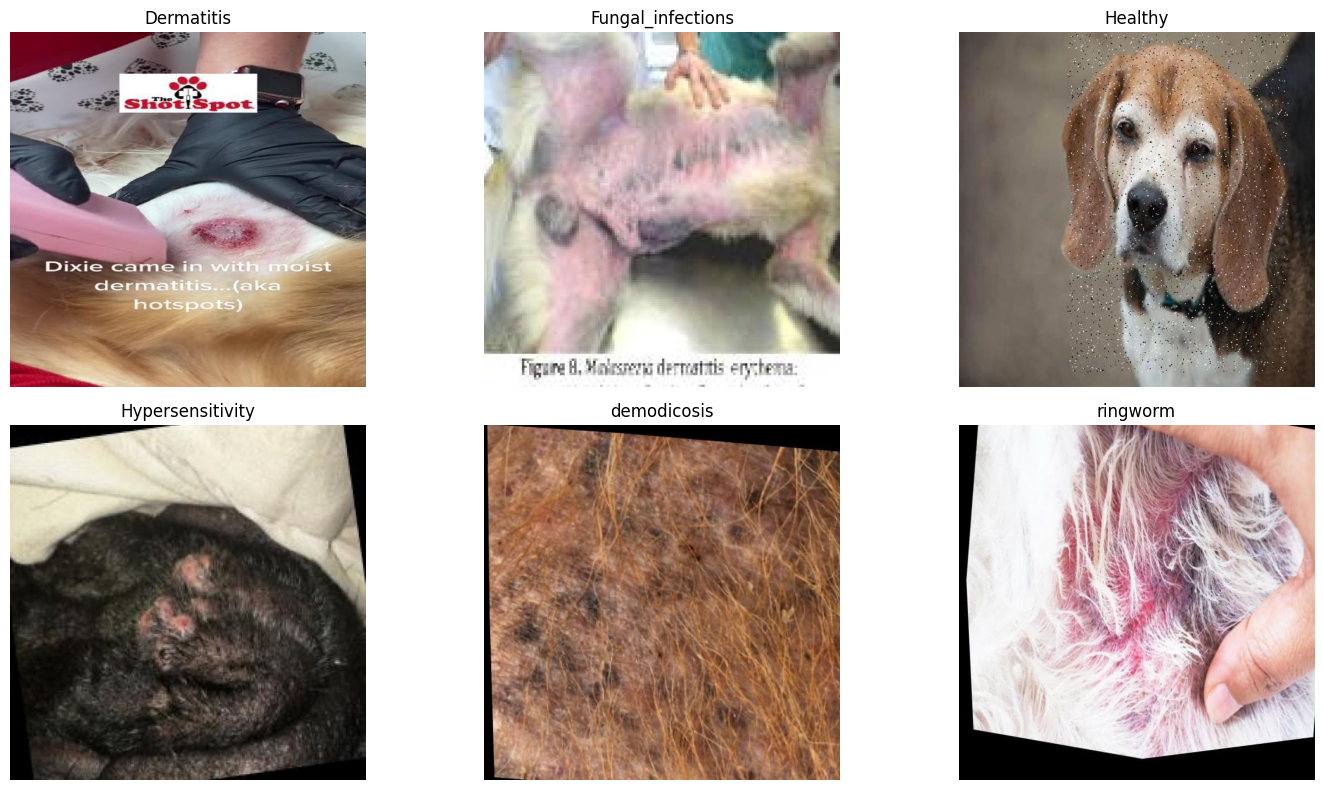

In [8]:
# Display one sample image from each disease class
plt.figure(figsize=(15, 8))

for i, c in enumerate(classes):
    # Get the first image from the current class
    class_path = os.path.join(train_dir, c)
    img_path = os.path.join(class_path, os.listdir(class_path)[0])

    # Open and display the image
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()

* Viewing one sample per class helps us sanity-check labels and get a feel for how
  visually similar/different the disease classes are before we start preprocessing.


### 3.3. Image Size, Format & Colour Channel Check

In [9]:
sizes, formats, channels = [], [], []

for c in classes:
    class_path = os.path.join(train_dir, c)
    for fname in os.listdir(class_path)[:20]:  # sample 20 images per class
        with Image.open(os.path.join(class_path, fname)) as img:
            sizes.append(img.size)
            formats.append(img.format)
            arr = np.array(img)
            channels.append(1 if arr.ndim == 2 else arr.shape[2])

print("Unique image sizes:", set(sizes))
print("Formats:", pd.Series(formats).value_counts().to_dict())
print("Channel counts:", pd.Series(channels).value_counts().to_dict())

Unique image sizes: {(640, 640)}
Formats: {'JPEG': 120}
Channel counts: {3: 120}


* All sampled images are **640x640 JPEG, 3-channel RGB** — a very consistent dataset.
* This tells us resizing/reshaping during preprocessing is mostly a safety net rather than
  a strict necessity, but we keep it in the pipeline in case unseen images differ.


## 4. Data Cleaning

### 4.1. Detecting Corrupt Images

In [10]:
def find_corrupt(directory):
    corrupt = []
    for c in os.listdir(directory):
        class_path = os.path.join(directory, c)
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception:
                corrupt.append(fpath)
    return corrupt

corrupt_files = find_corrupt(train_dir) + find_corrupt(valid_dir) + find_corrupt(test_dir)
print("Corrupt images found:", len(corrupt_files))

Corrupt images found: 0


* `img.verify()` checks file integrity without fully decoding the image — fast and
  memory-efficient for scanning thousands of files.
* Result: **0 corrupt images** — the dataset is safe to use as-is on this front.


### 4.2. Detecting & Removing Duplicate Images

In [11]:
def hash_images(directory):
    hashes = {}
    for c in os.listdir(directory):
        class_path = os.path.join(directory, c)
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            with open(fpath, "rb") as f:
                h = hashlib.md5(f.read()).hexdigest()
            hashes.setdefault(h, []).append(fpath)
    return hashes

all_hashes = {}
for split_dir in [train_dir, valid_dir, test_dir]:
    for h, paths in hash_images(split_dir).items():
        all_hashes.setdefault(h, []).extend(paths)

duplicates = {h: p for h, p in all_hashes.items() if len(p) > 1}
print("Duplicate groups found:", len(duplicates))

Duplicate groups found: 78


In [12]:
for paths in duplicates.values():
    print(paths)
    print("-" * 50)

['dataset/train/Fungal_infections/pic58_jpg.rf.14e546da0a6c7032e129f9fe86ce0579.jpg', 'dataset/train/Fungal_infections/pic58_jpg.rf.b57bb4de376f375c9244759506cbff4a.jpg']
--------------------------------------------------
['dataset/train/Fungal_infections/pic78_jpg.rf.2699f73a6b49efbc5b9a860c27c96bba.jpg', 'dataset/train/Fungal_infections/pic78_jpg.rf.16967e4ac0ced63b214ee6cd39ecfd1d.jpg']
--------------------------------------------------
['dataset/train/Fungal_infections/pic80_jpg.rf.db4c18e0575f576cc1ceee46e6a8f97f.jpg', 'dataset/valid/Fungal_infections/pic80_jpg.rf.a844273dbe1e7942d3a595aad8639c5f.jpg']
--------------------------------------------------
['dataset/train/Fungal_infections/Fungal_Image_1_jpg.rf.026c23f24e70860708396f58a3486ce1.jpg', 'dataset/train/Fungal_infections/Fungal_Image_1_jpg.rf.fd9aef06b62949d93b82710ae34fc386.jpg']
--------------------------------------------------
['dataset/train/Fungal_infections/Fungal3_png_jpg.rf.47fe1ecc36935ec8a12a0ee428aad05f.jpg', 'd

In [13]:
# Remove duplicate images from validation and test
removed = []

for paths in duplicates.values():
    if len(paths) > 1:
        train_file = next((p for p in paths if p.startswith(train_dir)), None)

        if train_file:
            for p in paths:
                if p != train_file:
                    os.remove(p)
                    removed.append(p)

print("Files removed:", len(removed))

Files removed: 76


In [14]:
# Count images after removing duplicates
train_counts = count_images(train_dir)
valid_counts = count_images(valid_dir)
test_counts = count_images(test_dir)

df_counts = pd.DataFrame({
    "Train": train_counts,
    "Validation": valid_counts,
    "Test": test_counts
})

df_counts["Total"] = df_counts.sum(axis=1)
df_counts.loc["Total"] = df_counts.sum()

df_counts

,Train,Validation,Test,Total
Dermatitis,545,174,66,785
Fungal_infections,349,87,51,487
Healthy,492,139,69,700
Hypersensitivity,209,53,25,287
demodicosis,588,174,100,862
ringworm,791,212,115,1118
Total,2974,839,426,4239


• We found 78 duplicate groups, including 30 duplicate groups shared across the training, validation, and test sets. These cross-split duplicates can cause data leakage because the model may encounter the same image during both training and evaluation, resulting in overly optimistic performance.

• To prevent data leakage, the training copy of each duplicate image was retained, while duplicate copies in the validation and test sets were removed. For duplicates within the same dataset split, only one copy was kept and the remaining duplicates were removed.


## 5. Data Preprocessing

### 5.1. Resizing and Normalizing Images

In [15]:
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/train",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

for images, labels in raw_train_ds.take(1):
    print("RAW IMAGE")
    print("Min:", images[0].numpy().min())
    print("Max:", images[0].numpy().max())

Found 2974 files belonging to 6 classes.
RAW IMAGE
Min: 0.0
Max: 251.64793


In [17]:
IMG_SIZE = (224, 224)   # standard input size for common CNN/transfer-learning backbones
BATCH_SIZE = 32

# Resizing is handled by image_dataset_from_directory (below); here we define
# a normalization layer that scales pixel values from [0, 255] to [0, 1]
normalization_layer = layers.Rescaling(1.0 / 255)

* We resize every image to **224x224** — a standard size that works well with common
  pretrained CNN backbones (e.g., MobileNet, ResNet), even though our raw images already
  happen to be 640x640.
* `Rescaling(1./255)` normalizes pixel values into the [0, 1] range, which helps the
  network train faster and more stably than using raw [0, 255] pixel values.


### 5.2. Data Augmentation (applied only to training data)

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [19]:
for images, labels in raw_train_ds.take(1):
    aug_img = data_augmentation(images)[0]

    print("AFTER AUGMENTATION")
    print("Min:", aug_img.numpy().min())
    print("Max:", aug_img.numpy().max())

AFTER AUGMENTATION
Min: 0.0
Max: 254.94577


* Augmentation creates realistic variations of the same image (flipped, slightly
  rotated, slightly zoomed) so the model sees more diversity without collecting new data.
* This directly helps with the class imbalance we found earlier — minority classes like
  Hypersensitivity benefit the most from augmentation during training.
* We only apply this to the **training** set — validation/test must reflect real,
  unaltered data for fair evaluation.


## 7. Final TensorFlow Data Pipeline

### 7.1. Building the Datasets

In [20]:
# Create training, validation, and test datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Display the class names
print("Class Names:", train_ds.class_names)

Found 2974 files belonging to 6 classes.
Found 839 files belonging to 6 classes.
Found 426 files belonging to 6 classes.
Class Names: ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


image_dataset_from_directory() automatically loads images from the training, validation, and test folders, resizes them to 224 × 224, groups them into batches, and assigns one-hot encoded labels (label_mode="categorical") for the six disease classes. This simplifies data loading and provides an efficient input pipeline for model training.

### 7.2. Applying Normalization, Augmentation & Performance Tuning

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

# Apply augmentation and normalization to the training set
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(data_augmentation(x)), y)
).cache().shuffle(1000).prefetch(AUTOTUNE)

# Apply only normalization to validation and test sets
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
).cache().prefetch(AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
).cache().prefetch(AUTOTUNE)

* `.map()` applies our augmentation and normalization functions to every image in the
  dataset.
* `.cache()` keeps images in memory after the first epoch so subsequent epochs load faster.
* `.shuffle(1000)` randomises the order of training images each epoch (important so the
  model doesn't learn any accidental ordering pattern).
* `.prefetch(AUTOTUNE)` lets TensorFlow prepare the next batch while the current one is
  still being used for training — this speeds up training significantly.


### 7.3. Displaying One Training Batch

In [26]:
import os

class_names = sorted(os.listdir("/content/dataset/train"))

print(class_names)

['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


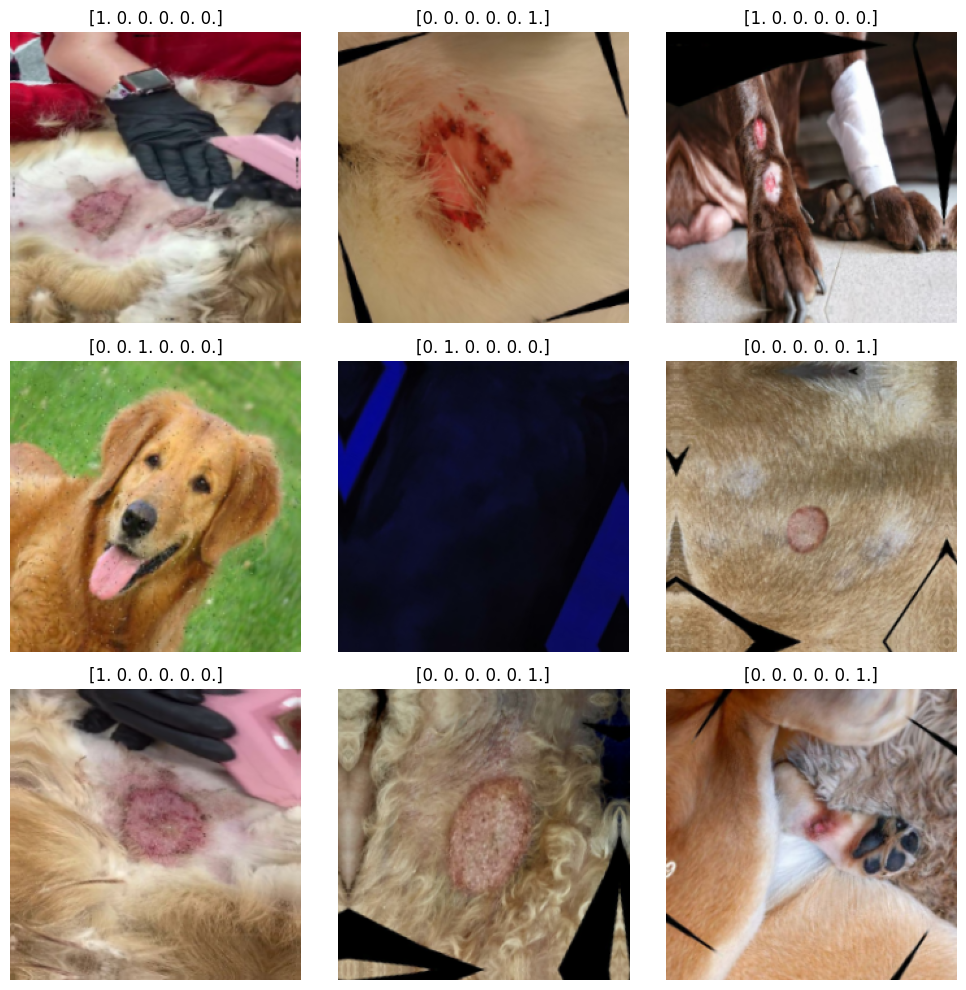

In [28]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy())

    plt.title(labels[i].numpy())

    plt.axis("off")

plt.tight_layout()
plt.show()

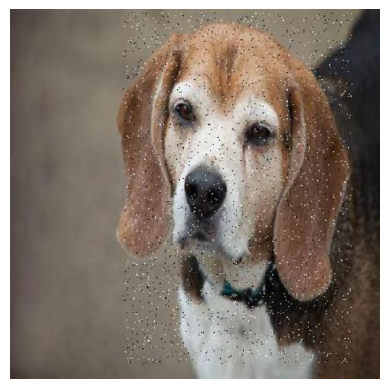

In [80]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img
import os

img_path = "/content/dataset/train/Healthy/" + os.listdir("/content/dataset/train/Healthy")[0]

img = load_img(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

* This final visual check confirms the whole pipeline works end-to-end: images are
  loaded, augmented, normalized, batched, and correctly labelled — ready to be handed
  to the modelling team.


### 7.4. Final Dataset Summary

In [38]:
# Final dataset summary
print("FINAL DATASET SUMMARY")
print("-" * 30)
print("Number of Classes:", len(train_counts))
print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Normalization: Rescaling (1/255)")
print("Data Augmentation: Applied to training set")
print("Training Batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation Batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test Batches:", tf.data.experimental.cardinality(test_ds).numpy())
print("Duplicate Files Removed:", len(removed))

FINAL DATASET SUMMARY
------------------------------
Number of Classes: 6
Image Size: (224, 224)
Batch Size: 32
Normalization: Rescaling (1/255)
Data Augmentation: Applied to training set
Training Batches: 93
Validation Batches: 27
Test Batches: 14
Duplicate Files Removed: 76


Uploading cleaned datset, to drive for further training

In [58]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import os

print(os.listdir("/content/dataset"))

['test', 'train', 'valid']


In [59]:
import shutil
import os

source = "/content/dataset"

destination = "/content/drive/MyDrive/Cleaned_Final_Dataset"

# create/copy
shutil.copytree(source, destination, dirs_exist_ok=True)

print("Finished copying!")

Finished copying!
